In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('DataSets/Churn_Modelling.csv')

In [3]:
df.shape

(10000, 14)

In [4]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
def visualization (x, y, xlabel):
    plt.figure(figsize=(10,5))
    plt.hist([x, y], color=['red', 'green'], label =  ['exit', 'not_exit'])
    plt. xlabel (xlabel, fontsize=20)
    plt.ylabel("No. of customer", fontsize=20)
    plt.legend()

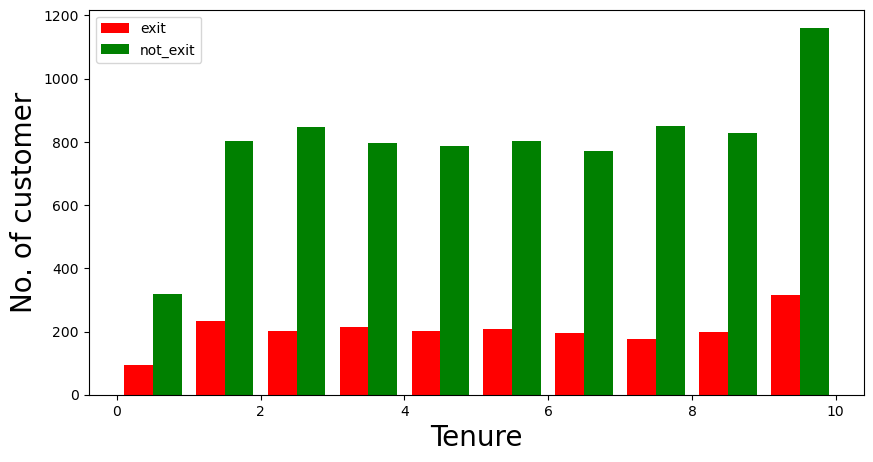

In [8]:
df_churn_exited = df[df['Exited']==1]['Tenure']
df_churn_not_exited = df[df['Exited']==0]['Tenure']
visualization(df_churn_exited,df_churn_not_exited, "Tenure")

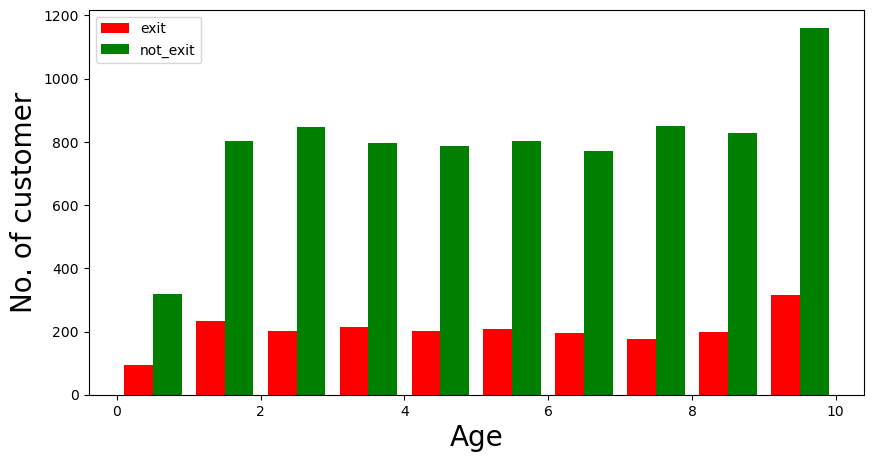

In [9]:
df_churn_exited2 = df[df['Exited']==1]['Age']
df_churn_not_exited2 = df[df['Exited']==0]['Age']
visualization(df_churn_exited,df_churn_not_exited, "Age")

In [10]:
x = df[['CreditScore','Age', 'Tenure', 'Balance' ,'NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']]

#output data 
y = df['Exited']

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler =StandardScaler()

In [13]:
x_scaled = scaler.fit_transform(x)

In [14]:
x_scaled

array([[-0.32622142,  0.29351742, -1.04175968, ...,  0.64609167,
         0.97024255,  0.02188649],
       [-0.44003595,  0.19816383, -1.38753759, ..., -1.54776799,
         0.97024255,  0.21653375],
       [-1.53679418,  0.29351742,  1.03290776, ...,  0.64609167,
        -1.03067011,  0.2406869 ],
       ...,
       [ 0.60498839, -0.27860412,  0.68712986, ..., -1.54776799,
         0.97024255, -1.00864308],
       [ 1.25683526,  0.29351742, -0.69598177, ...,  0.64609167,
        -1.03067011, -0.12523071],
       [ 1.46377078, -1.04143285, -0.35020386, ...,  0.64609167,
        -1.03067011, -1.07636976]], shape=(10000, 8))

In [15]:
#cross-validation
from sklearn.model_selection import train_test_split

In [16]:
x_train , x_test, y_train, y_test = train_test_split(x_scaled , y,
                 random_state=42, test_size=0.25)

In [17]:
x.shape

(10000, 8)

In [18]:
x_test.shape

(2500, 8)

In [19]:
x_train.shape

(7500, 8)

In [20]:
from sklearn.neural_network import MLPClassifier

In [21]:
ann = MLPClassifier(hidden_layer_sizes=(100,100,100),
                random_state=0,
                    max_iter=100,
                        activation='relu')

In [22]:
ann.fit(x_train , y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(100, 100, 100), max_iter=100, random_state=0)

In [23]:
y_pred = ann.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score

In [25]:
y_test.value_counts()

Exited
0    2003
1     497
Name: count, dtype: int64

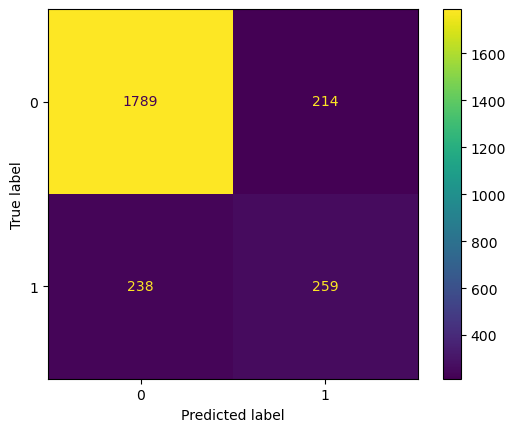

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test , y_pred)

In [27]:
accuracy = f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%"

In [28]:
accuracy

'Accuracy: 81.92%'

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      2003
           1       0.55      0.52      0.53       497

    accuracy                           0.82      2500
   macro avg       0.72      0.71      0.71      2500
weighted avg       0.82      0.82      0.82      2500

